# Comparison of integration methods

| Date | Who | Mail |  What |
| ---  | --- | ---  | ---   |     
| Jul 11, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Initial code created using Gemini 3.1 Pro |
| Jul 11, 2026 | Diego Andrés Alvarez Marín | <daalvarez@unal.edu.co>  | Improvements to code and comments |


## 1. Introduction to the Target Integral

Here, we will approximate the following integrals:
$$
I = \int_{0}^{1} \frac{4}{1 + x^2} dx = \pi \approx 3.141592653589793
$$

$$
I = \int_{1}^{2} \frac{1}{x} dx = \ln(2) \approx 0.693147180559945
$$

$$
I = \int_{-1}^{1} \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right) dx \approx 0.682689492137086
$$

Because we know the exact answer, we can perfectly calculate the absolute and relative errors of our numerical approximations.

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
# Define the function to integrate
def f1(x):
    return 4/(1 + x**2)

# Integration limits
a1 = 0.0
b1 = 1.0

# Exact mathematical solution
exact_val1 = np.pi

In [31]:
# Define the function to integrate
def f2(x):
    return 1/x

# Integration limits
a2 = 1.0
b2 = 2.0

# Exact mathematical solution
exact_val2 = np.log(2)

In [32]:
# Define the function to integrate
def f3(x):
    return 1/np.sqrt(2*np.pi) * np.exp(-x**2/2)

# Integration limits
a3 = -1.0
b3 =  1.0

# Exact mathematical solution
from scipy.stats import norm
exact_val3 = norm.cdf(b3) - norm.cdf(a3)

Let's choose the functions and their integration limits for the two integrals we will approximate.

In [33]:
# Select the function and limits for the integration
f = f3
a = a3
b = b3
exact_val = exact_val3

print(f"Exact value: {exact_val:.15f}")

Exact value: 0.682689492137086


---

## 2. Implementing the Numerical Methods

Numerical integration approximates the integral by evaluating the function at specific points and calculating a weighted sum. In this notebook we will deal with the **Newton-Cotes formulas**, which divide the interval $[a, b]$ into $n$ equal subintervals of width $h = \frac{b-a}{n}$.

| Method | Subintervals Required ($n$) | Underlying Polynomial Degree | Error Order in Composite Rule |
| --- | --- | --- | --- |
| **Midpoint** | Any integer $\ge 1$ | 0 (Constant) | $\mathcal{O}(h^2)$ |
| **Trapezoidal** | Any integer $\ge 1$ | 1 (Linear) | $\mathcal{O}(h^2)$ |
| **Simpson's 1/3** | Multiple of 2 | 2 (Quadratic) | $\mathcal{O}(h^4)$ |
| **Simpson's 3/8** | Multiple of 3 | 3 (Cubic) | $\mathcal{O}(h^4)$ |
| **Boole's Rule** | Multiple of 4 | 4 (Quartic) | $\mathcal{O}(h^6)$ |
| **Newton-Cotes 6 Rule** | Multiple of 6 | 6 (Hexic) | $\mathcal{O}(h^8)$ |

**Romberg Integration** uses Richardson Extrapolation on the Trapezoidal rule to systematically eliminate error terms, providing highly accurate results without needing new quadrature weights.


## 3. Python Implementation

The following Python code defines the composite versions of all these rules.

### Midpoint Rule

The Midpoint rule approximates the integral by summing the areas of rectangles. For each subinterval, the height of the rectangle is determined by the function's value at the midpoint of that subinterval. This method uses a constant (0-degree) polynomial to approximate the function within each subinterval.

In [34]:
def midpoint(f, a, b, n):
    h = (b - a)/n
    x = np.linspace(a + h/2, b - h/2, n)
    return h * np.sum(f(x))

### Trapezoidal Rule

The Trapezoidal rule approximates the area under the curve using linear segments (trapezoids).

In [35]:
def trapezoidal(f, a, b, n):
    h = (b - a)/n
    x = np.linspace(a, b, n+1)
    y = f(x)

    # h/2 * [f(x_0) + 2*f(x_1) + ... + 2*f(x_{n-1}) + f(x_n)]
    integral = (h/2) * (y[0] + 2*np.sum(y[1:-1]) + y[-1])
    return integral

### Simpson's 1/3 Rule

Simpson's 1/3 rule uses quadratic parabolas to interpolate between three points. **Note:** This method requires $n$ to be a multiple of 2 (i.e. an even number).

In [36]:
def simpson_13(f, a, b, n):
    if n%2 != 0:
        raise ValueError("Simpson_13: n must be a multiple of 2.")

    h = (b - a)/n
    x = np.linspace(a, b, n+1)
    y = f(x)

    integral = 0
    for i in range(0, n, 2):
        integral += (h/3) * (y[i] + 4*y[i+1] + y[i+2])
    return integral

### Simpson's 3/8 Rule

Simpson's 3/8 rule uses cubic interpolation across four points. **Note:** This method requires $n$ to be a multiple of 3.

In [37]:
def simpson_38(f, a, b, n):
    if n%3 != 0:
        raise ValueError("Simpson_38: n must be a multiple of 3.")

    h = (b - a)/n
    x = np.linspace(a, b, n+1)
    y = f(x)

    integral = 0
    for i in range(0, n, 3):
        integral += (3*h/8) * (y[i] + 3*y[i+1] + 3*y[i+2] + y[i+3])
    return integral

### Boole's Rule

Boole's rule (sometimes called Bode's rule) is the Newton-Cotes formula that interpolates a 4th-degree polynomial across 5 points. **Note:** This method requires $n$ to be a multiple of 4.

In [38]:
def booles(f, a, b, n):
    if n%4 != 0:
        raise ValueError("n must be a multiple of 4")
    
    h = (b - a)/n
    x = np.linspace(a, b, n+1)
    y = f(x)
    
    integral = 0
    for i in range(0, n, 4):
        integral += (2*h/45) * (7*y[i] + 32*y[i+1] + 12*y[i+2] + 32*y[i+3] + 7*y[i+4])
    return integral

### Newton-Cotes 6 Rule

Newton-Cotes 6 rule achieves 6th-order accuracy. **Note:** This method requires $n$ to be a multiple of 6.

In [39]:
def NC6(f, a, b, n):
    if n%6 != 0:
        raise ValueError("n must be a multiple of 6")

    h = (b - a)/n
    x = np.linspace(a, b, n+1)
    y = f(x)
    
    integral = 0
    for i in range(0, n, 6):
        integral += (h/140) * (41*y[i] + 216*y[i+1] + 27*y[i+2] + 272*y[i+3] + 27*y[i+4] + 216*y[i+5] + 41*y[i+6])
    return integral

### Romberg Rule

Romberg integration evaluates the Trapezoidal rule at sequential powers of 2 (i.e., $n = 1, 2, 4, 8...$) and uses Richardson extrapolation to systematically cancel out error terms, creating a highly accurate result.

In [40]:
def romberg(f, a, b, n):
    # n dictates the depth k, where n = 2^k. We find k based on n.
    k = int(np.log2(n))
    R = np.zeros((k+1, k+1))
    for i in range(k+1):
        # First column is the standard trapezoidal rule
        R[i, 0] = trapezoidal(f, a, b, 2**i)

        # Richardson extrapolation for higher-order accuracy
        for j in range(1, i+1):
            R[i, j] = R[i, j-1] + (R[i, j-1] - R[i-1, j-1])/(4**j - 1)

    # The best estimate is the bottom-right element
    return R[k, k]


## 4. Comparing Errors: Plotting Against $n$

To plot all of these together, we need values of $n$ that satisfy the requirements for all methods.

* Simpson's 1/3 requires multiples of 2.
* Simpson's 3/8 requires multiples of 3.
* Boole's requires multiples of 4.
* NC6 requires multiples of 6.

The least common multiple (LCM) of 2, 3, 4, and 6 is **12**. Therefore, we will step our interval $n$ by multiples of 12 so that no method throws a `ValueError`.

Romberg naturally operates on $n=2^k$, so we will plot its equivalent $n$ independently.

In [41]:
# Setup comparison arrays
n_values         = np.arange(12, int(2**9), 12) # Multiples of 12: 12, 24, 36, 48, ..., 504
romberg_n_values = 2**np.arange(2, 9)           # Powers of 2: 2, 4, 8, 16, 32, 64, 128, 256

results = {
    "Midpoint":    (        n_values, [midpoint   (f, a, b, n) for n in         n_values]),
    "Trapezoidal": (        n_values, [trapezoidal(f, a, b, n) for n in         n_values]),
    "Simpson 1/3": (        n_values, [simpson_13 (f, a, b, n) for n in         n_values]),
    "Simpson 3/8": (        n_values, [simpson_38 (f, a, b, n) for n in         n_values]),
    "Boole's":     (        n_values, [booles     (f, a, b, n) for n in         n_values]),
    "NC6":         (        n_values, [NC6        (f, a, b, n) for n in         n_values]),
    "Romberg":     (romberg_n_values, [romberg    (f, a, b, n) for n in romberg_n_values])
}


Now, let's plot the results:

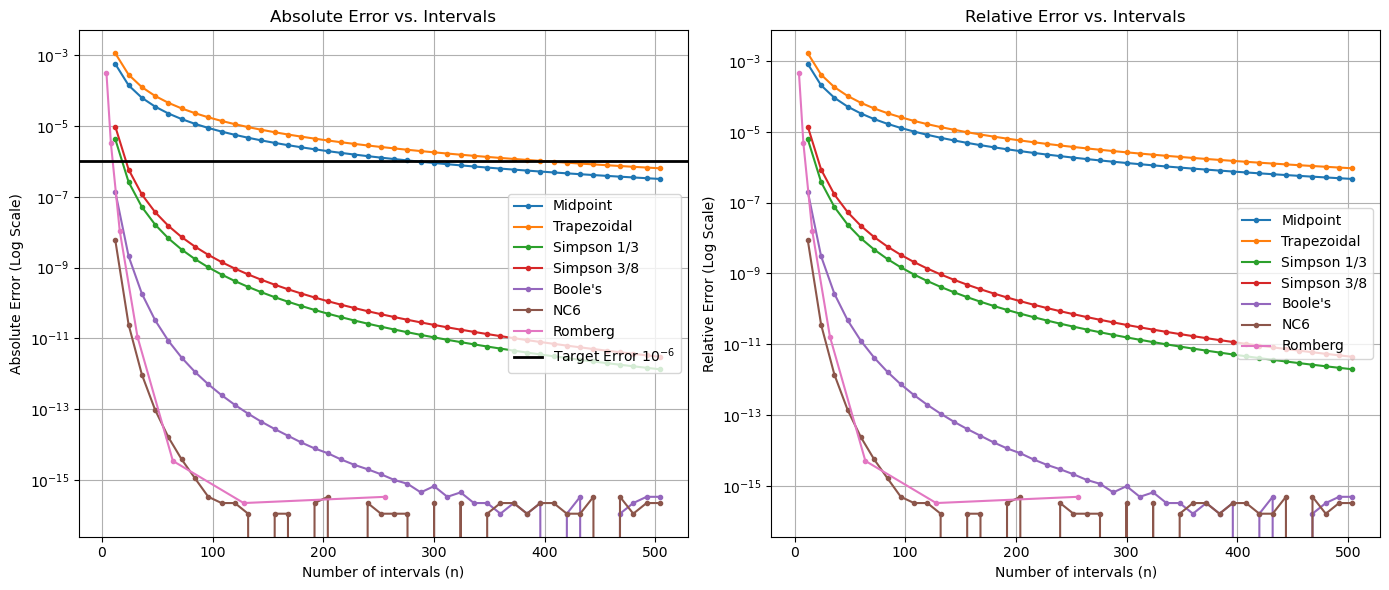

In [42]:
# Plotting Errors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Absolute Error Plot
for name, (ns, vals) in results.items():
    abs_errors = abs(np.array(vals) - exact_val)
    ax1.plot(ns, abs_errors, marker='.', label=name)
#ax1.set_xscale('log')
#x1.set_xlim([0,50])
ax1.axhline(y=10**-6, linewidth=2, color='black', label='Target Error $10^{-6}$')
ax1.set_yscale('log')
ax1.set_xlabel('Number of intervals (n)')
ax1.set_ylabel('Absolute Error (Log Scale)')
ax1.set_title('Absolute Error vs. Intervals')
ax1.grid(True, which="both")
ax1.legend(loc='right')

# Relative Error Plot
for name, (ns, vals) in results.items():
    rel_errors = abs(np.array(vals) - exact_val)/exact_val
    ax2.plot(ns, rel_errors, marker='.', label=name)
#ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Number of intervals (n)')
ax2.set_ylabel('Relative Error (Log Scale)')
ax2.set_title('Relative Error vs. Intervals')
ax2.grid(True, which="both")
ax2.legend(loc='right')

plt.tight_layout()
plt.show()

### What to Look For in the Plot

Notice the slopes of the lines on the log-log plot.

* The **Trapezoidal** line decreases slowly (slope of roughly -2), matching its $O(n^{-2})$ error rate.
* The **Simpson's** lines fall off much more steeply (slope of roughly -4), matching their $O(n^{-4})$ error rate. They will largely overlap, though Simpson's 1/3 is often marginally more accurate per interval than 3/8.
* The **Boole's** and **NC6** lines drop significantly steeper than Simpson's ($O(n^{-6})$ and $O(n^{-8})$ vs $O(n^{-4})$).
* The **Romberg** line plummets the fastest. Because it extrapolates higher-order accuracy, it achieves near-machine precision with incredibly few intervals compared to the other methods.

Observe that Boole's, Weddle's and Romberg's rules will hit the numerical precision limit (around $10^{-15}$ for 64-bit floating-point) faster than the other methods.

## Integration Rules and Error Bounds

This table outlines the theoretical global truncation error bounds for each composite integration method based on step size $h = \frac{b-a}{n}$.

| Rule | Required Multiples of $n$ | Error Bound Formula |
| --- | --- | --- |
| **Trapezoidal** | Any integer | $\vert{}E_T\vert{} \le \frac{(b-a)^3}{12n^2} \max \vert{}f''(x)\vert{}$ |
| **Simpson's 1/3** | Multiples of 2 | $\vert{}E_{S1/3}\vert{} \le \frac{(b-a)^5}{180n^4} \max \vert{}f^{(4)}(x)\vert{}$ |
| **Simpson's 3/8** | Multiples of 3 | $\vert{}E_{S3/8}\vert{} \le \frac{(b-a)^5}{80n^4} \max \vert{}f^{(4)}(x)\vert{}$ |
| **Boole's** | Multiples of 4 | $\vert{}E_B\vert{} \le \frac{8(b-a)^7}{945n^6} \max \vert{}f^{(6)}(x)\vert{}$ |

## Analysis of the theoretical error for integrating the standard normal distribution curve over the interval $[-1, 1]$.

### Theoretical Error Analysis

To determine the number of intervals $n$ required to guarantee a specific tolerance (such as $\epsilon = 10^{-6}$) for the integral $\int_{-1}^{1} \frac{1}{\sqrt{2\pi}} e^{-x^2/2} dx$, we must first find the maximum magnitude of the relevant derivatives of our function $f(x) = \frac{1}{\sqrt{2\pi}} e^{-x^2/2}$ on the interval $[-1, 1]$.

Because this interval is centered around $x=0$, the maximum magnitudes for the even derivatives all occur at the peak of the bell curve ($x=0$):

* **Second derivative:** $f''(x) = \frac{x^2 - 1}{\sqrt{2\pi}} e^{-x^2/2}$
$\max \vert{}f''(x)\vert{} = \vert{}f''(0)\vert{} = \frac{1}{\sqrt{2\pi}} \approx 0.3989$
* **Fourth derivative:** $f^{(4)}(x) = \frac{x^4 - 6x^2 + 3}{\sqrt{2\pi}} e^{-x^2/2}$
$\max \vert{}f^{(4)}(x)\vert{} = \vert{}f^{(4)}(0)\vert{} = \frac{3}{\sqrt{2\pi}} \approx 1.1968$
* **Sixth derivative:** $f^{(6)}(x) = \frac{x^6 - 15x^4 + 45x^2 - 15}{\sqrt{2\pi}} e^{-x^2/2}$
$\max \vert{}f^{(6)}(x)\vert{} = \vert{}f^{(6)}(0)\vert{} = \frac{15}{\sqrt{2\pi}} \approx 5.9841$

With $b-a = 2$, we can calculate the required intervals $n$ for a target error of $\epsilon = 10^{-6}$.

#### Trapezoidal Rule (Order 2)

The theoretical bound relies on the second derivative:

$$\frac{(b-a)^3}{12 n^2} \max \vert{}f''(x)\vert{} \le 10^{-6}$$

$$\frac{2^3}{12 n^2} (0.3989) \le 10^{-6}$$

$$\frac{3.1912}{12 n^2} \le 10^{-6} \implies n^2 \ge 265,933 \implies n \ge 515.7$$

**Result:** You need **516 intervals** to guarantee an accuracy of $10^{-6}$.

#### Simpson's 1/3 Rule (Order 4)

The theoretical bound relies on the fourth derivative:

$$\frac{(b-a)^5}{180 n^4} \max \vert{}f^{(4)}(x)\vert{} \le 10^{-6}$$

$$\frac{2^5}{180 n^4} (1.1968) \le 10^{-6}$$

$$\frac{38.2976}{180 n^4} \le 10^{-6} \implies n^4 \ge 212,764 \implies n \ge 21.47$$

**Result:** Because $n$ must be an even integer, you need **22 intervals**.

#### Boole's Rule (Order 6)

The theoretical bound relies on the sixth derivative:

$$\frac{8(b-a)^7}{945 n^6} \max \vert{}f^{(6)}(x)\vert{} \le 10^{-6}$$

$$\frac{8(128)}{945 n^6} (5.9841) \le 10^{-6}$$

$$\frac{6127.7}{945 n^6} \le 10^{-6} \implies n^6 \ge 6,484,357 \implies n \ge 13.65$$

**Result:** Because $n$ must be a multiple of 4, you need **16 intervals**.